In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv(r"Salary_dataset.csv")

In [3]:
dataset

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [4]:
dataset = dataset.drop(columns = ["Unnamed: 0"])

In [5]:
dataset

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [6]:
dataset.isnull().sum()


YearsExperience    0
Salary             0
dtype: int64

In [7]:
x = dataset[["YearsExperience"]]
y = dataset[["Salary"]]

In [8]:
import numpy as np
import matplotlib.pyplot as plt

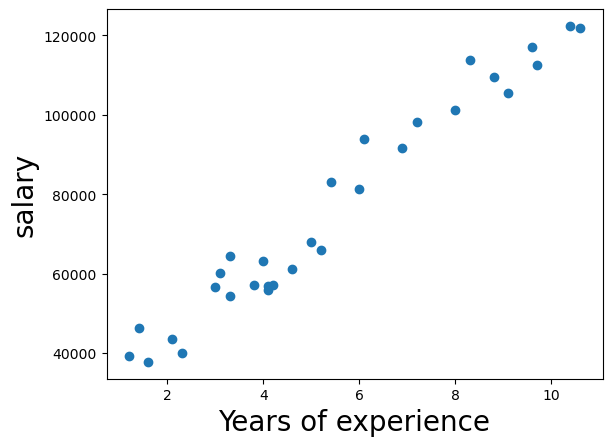

In [9]:
plt.scatter(x,y)
plt.xlabel('Years of experience', fontsize=20)
plt.ylabel('salary', fontsize=20)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state=0)

In [15]:
y_test

,Salary
2,37732.0
28,122392.0
13,57082.0
10,63219.0
26,116970.0
24,109432.0
27,112636.0
11,55795.0
17,83089.0


In [16]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
weight = regressor.coef_
print("Weight of the model = {}".format(weight))
bais = regressor.intercept_
print("Bais of the model = {}".format(bais))

Weight of the model = [[9360.26128619]]
Bais of the model = [25842.36521258]


In [19]:
y_pred = regressor.predict(x_test)

In [20]:
y_pred

array([[ 40818.78327049],
       [123189.08258899],
       [ 65155.46261459],
       [ 63283.41035735],
       [115700.87356004],
       [108212.66453108],
       [116636.89968866],
       [ 64219.43648597],
       [ 76387.77615802]])

In [22]:
from sklearn.metrics import r2_score
ad = r2_score(y_test, y_pred)*100
ad

97.4099340721351

In [23]:
import pickle
filename = "linear_regression_model.sav"
pickle.dump(regressor, open(filename, 'wb'))

In [24]:
loadedmodel = pickle.load(open('linear_regression_model.sav', 'rb'))
result = loadedmodel.predict([[35]])
print(result)
                          

[[353451.51022936]]


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
x = float(input("Enter the years of experience: "))
future_prediction = regressor.predict([[x]])
print("Your salary is:{}".format(future_prediction))

Enter the years of experience:  10


Your salary is:[[119444.97807451]]


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
